In [1]:
import time
import pandas as pd
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

import spacy
import torch
import torch.nn as nn
import torch.optim as optim

### Dataset Creation

In [2]:
df = pd.read_csv("train_with_task_type.csv")
task_types = set(df["task_type"])

X, y = df["prompt"], df["task_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
results = []

### Pipeline #1: TF-IDF + Naive Bayes

In [3]:
model = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

start_train = time.time()
model.fit(X_train, y_train)
end_train = time.time()
print(f"Training Time: {end_train - start_train:.3f}s") # training time

start_inf = time.time()
y_pred = model.predict(X_test)
end_inf = time.time()
print(f"Inference Time: {end_inf - start_inf:.3f}s") # inference time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

matrix = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{matrix}")

results.append({
    "Pipeline": "TF-IDF + Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Training Time": end_train - start_train,
    "Inference Time": end_inf - start_inf
})

Training Time: 0.123s
Inference Time: 0.026s
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-Score:  1.000

Confusion Matrix:
[[322   0   0   0   0   0]
 [  0 301   0   0   0   0]
 [  0   0 346   0   0   0]
 [  0   0   0 306   0   0]
 [  0   0   0   0 313   0]
 [  0   0   0   0   0 312]]


### Pipeline #2: Word2Vec + Neural Network

In [4]:
# This pipeline takes ~50 seconds to run
# 
# run this command to load pretrained word2vec embedding model: 
# !python3 -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

""" creating class indicies """
classes = list(set(y))
ctoi, itoc = {}, {}
for i in range(len(classes)):
    ctoi[classes[i]] = i
    itoc[i] = classes[i]

""" creating document vectors via mean pooling """
start_nlp = time.time()
nlpX_train = np.array([
    doc.vector
    for doc in nlp.pipe(X_train, batch_size=100, disable=["tagger", "parser", "ner"])
])
nlpX_test = np.array([
    doc.vector
    for doc in nlp.pipe(X_test, batch_size=100, disable=["tagger", "parser", "ner"])
])

nlpy_train = np.array([
    ctoi[text] for text in y_train
])

nlpy_test = np.array([
    ctoi[text] for text in y_test
])
end_nlp = time.time()

nlpX_train, nlpX_test = torch.tensor(nlpX_train), torch.tensor(nlpX_test)
nlpy_train, nlpy_test = torch.tensor(nlpy_train, dtype=torch.long), torch.tensor(nlpy_test, dtype=torch.long)
    
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(300, 300),
            nn.ReLU(),
            nn.Linear(300, len(classes))
        )  
    
    def forward(self, x):
        return self.model(x)

model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

""" training loop """
epochs = 500
start_train = time.time()
for i in range(epochs):
    optimizer.zero_grad()

    out = model(nlpX_train)
    loss = criterion(out, nlpy_train)

    loss.backward()
    optimizer.step()
end_train = time.time()

""" evaluating accuracy """
start_inf = time.time()
with torch.no_grad():
    out = model(nlpX_test)
    prediction = torch.argmax(out, dim=1)
end_inf = time.time()

y_true = nlpy_test.numpy()
y_pred = prediction.numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nData Preprocessing Time: {end_nlp - start_nlp:.4f}s")
print(f"Training Time:           {end_train - start_train:.4f}s")
print(f"Inference Time:          {end_inf - start_inf:.4f}s")

results.append({
    "Pipeline": "Word2Vec + Neural Network",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Training Time": end_train - start_train,
    "Inference Time": end_inf - start_inf,
    "Preprocessing Time": end_nlp - start_nlp
})

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Accuracy:  0.9363
Precision: 0.9527
Recall:    0.9363
F1-Score:  0.9330

Data Preprocessing Time: 43.2200s
Training Time:           2.8679s
Inference Time:          0.0018s


### Pipeline #3: TF-IDF + K-Nearest Neighbors

In [5]:
model = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', KNeighborsClassifier())
])

start_train = time.time()
model.fit(X_train, y_train)
end_train = time.time()
print(f"Training Time: {end_train - start_train:.3f}s") # training time

start_inf = time.time()
y_pred = model.predict(X_test)
end_inf = time.time()
print(f"Inference Time: {end_inf - start_inf:.3f}s") # inference time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")

matrix = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{matrix}")

results.append({
    "Pipeline": "TF-IDF + KNN",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Training Time": end_train - start_train,
    "Inference Time": end_inf - start_inf
})

Training Time: 0.115s
Inference Time: 1.473s
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-Score:  1.000

Confusion Matrix:
[[322   0   0   0   0   0]
 [  0 301   0   0   0   0]
 [  0   0 346   0   0   0]
 [  0   0   0 306   0   0]
 [  0   0   0   0 313   0]
 [  0   0   0   0   0 312]]


### Visualizations

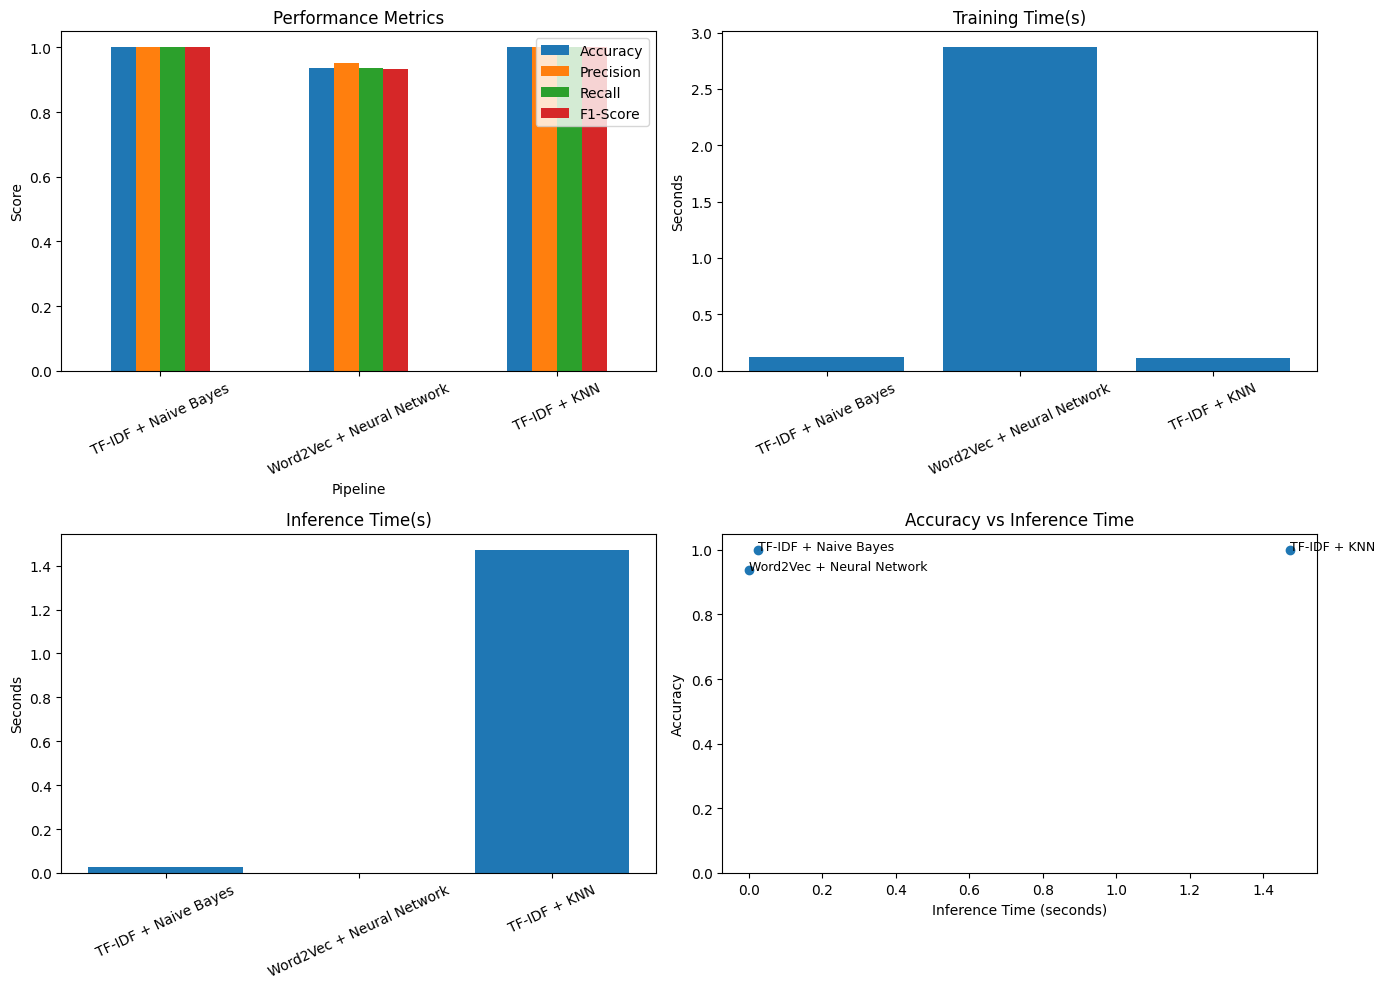

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

results_df.plot(
    x="Pipeline",
    y=["Accuracy", "Precision", "Recall", "F1-Score"],
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Performance Metrics")
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].tick_params(axis='x', rotation=25)

axes[0, 1].bar(results_df["Pipeline"], results_df["Training Time"])
axes[0, 1].set_title("Training Time(s)")
axes[0, 1].set_ylabel("Seconds")
axes[0, 1].tick_params(axis='x', rotation=25)

axes[1, 0].bar(results_df["Pipeline"], results_df["Inference Time"])
axes[1, 0].set_title("Inference Time(s)")
axes[1, 0].set_ylabel("Seconds")
axes[1, 0].tick_params(axis='x', rotation=25)

axes[1, 1].scatter(
    results_df["Inference Time"],
    results_df["Accuracy"]
)

for i, row in results_df.iterrows():
    axes[1, 1].text(
        row["Inference Time"],
        row["Accuracy"],
        row["Pipeline"],
        fontsize=9
    )

axes[1, 1].set_title("Accuracy vs Inference Time")
axes[1, 1].set_xlabel("Inference Time (seconds)")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()